# Loading The Data

In [3]:
import pandas as pd


In [4]:
data=pd.read_csv("../data/raw/mining_block_model.csv")

In [5]:
print(data.shape)

(75000, 13)


In [6]:
print(data.columns)

Index(['Block_ID', 'X', 'Y', 'Z', 'Rock_Type', 'Ore_Grade (%)', 'Tonnage',
       'Ore_Value_Per_Tonne_Yen', 'Mining_Cost_Yen', 'Processing_Cost_Yen',
       'Waste_Flag', 'Profit_Yen', 'Target'],
      dtype='str')


In [7]:
data.head()

,Block_ID,X,Y,Z,Rock_Type,Ore_Grade (%),Tonnage,Ore_Value_Per_Tonne_Yen,Mining_Cost_Yen,Processing_Cost_Yen,Waste_Flag,Profit_Yen,Target
0,B00001,102,186,6,Magnetite,51.93,2131,294.48,53,38,0,433615.88,1
1,B00002,435,448,82,Hematite,59.05,1550,273.00,36,33,0,316200.00,1
2,B00003,348,476,94,Magnetite,63.79,2414,338.36,57,28,0,611611.04,1
3,B00004,270,127,98,Hematite,64.98,1297,307.60,30,29,0,322434.20,1
4,B00005,106,111,92,Waste,0.00,1309,0.00,67,28,1,-124355.00,0


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Block_ID                 75000 non-null  str    
 1   X                        75000 non-null  int64  
 2   Y                        75000 non-null  int64  
 3   Z                        75000 non-null  int64  
 4   Rock_Type                75000 non-null  str    
 5   Ore_Grade (%)            75000 non-null  float64
 6   Tonnage                  75000 non-null  int64  
 7   Ore_Value_Per_Tonne_Yen  75000 non-null  float64
 8   Mining_Cost_Yen          75000 non-null  int64  
 9   Processing_Cost_Yen      75000 non-null  int64  
 10  Waste_Flag               75000 non-null  int64  
 11  Profit_Yen               75000 non-null  float64
 12  Target                   75000 non-null  int64  
dtypes: float64(3), int64(8), str(2)
memory usage: 8.4 MB


In [9]:
data.describe()

,X,Y,Z,Ore_Grade (%),Tonnage,Ore_Value_Per_Tonne_Yen,Mining_Cost_Yen,Processing_Cost_Yen,Waste_Flag,Profit_Yen,Target
count,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000
mean,249.242680,248.773240,49.525360,45.992171,2000.475080,239.848683,49.563547,29.512120,0.200293,322005.651984,0.799707
std,144.613539,143.852756,28.858031,23.343018,577.028563,122.777574,11.526363,5.772658,0.400223,273713.865800,0.400223
min,0.000000,0.000000,0.000000,0.000000,1000.000000,0.000000,30.000000,20.000000,0.000000,-317152.000000,0.000000
25%,123.000000,124.000000,24.000000,50.920000,1501.000000,256.170000,40.000000,24.000000,0.000000,238527.937500,1.000000
50%,249.000000,248.000000,50.000000,55.620000,2003.000000,287.290000,50.000000,29.000000,0.000000,378189.050000,1.000000
75%,375.000000,373.000000,75.000000,60.340000,2501.000000,318.610000,60.000000,35.000000,0.000000,516542.122500,1.000000
max,499.000000,499.000000,99.000000,65.000000,2999.000000,350.000000,69.000000,39.000000,1.000000,883522.030000,1.000000


In [10]:
data.isnull().sum()

Block_ID                   0
X                          0
Y                          0
Z                          0
Rock_Type                  0
Ore_Grade (%)              0
Tonnage                    0
Ore_Value_Per_Tonne_Yen    0
Mining_Cost_Yen            0
Processing_Cost_Yen        0
Waste_Flag                 0
Profit_Yen                 0
Target                     0
dtype: int64

In [11]:
data.Target.value_counts()

Target
1    59978
0    15022
Name: count, dtype: int64

In [12]:

import matplotlib.pyplot as plt
import seaborn as sns


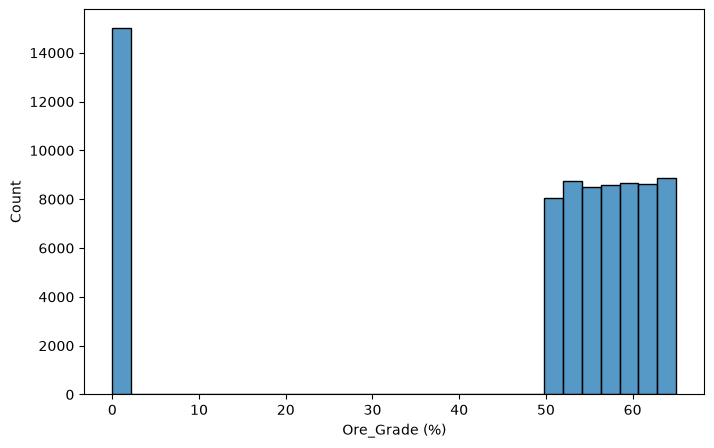

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data["Ore_Grade (%)"],bins=30)
plt.show()

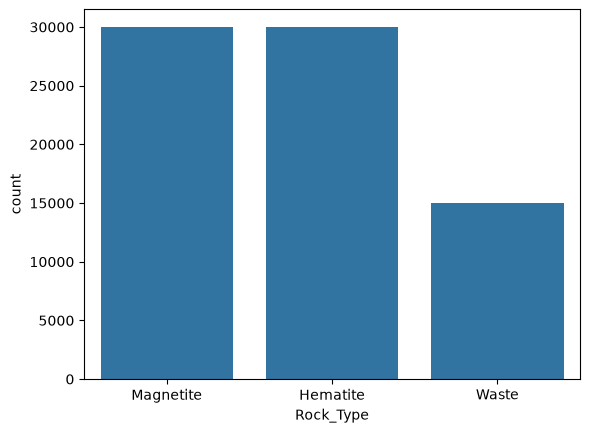

In [14]:
sns.countplot(x="Rock_Type",data=data)
plt.show()

In [15]:
print(data.Target.unique())

[1 0]


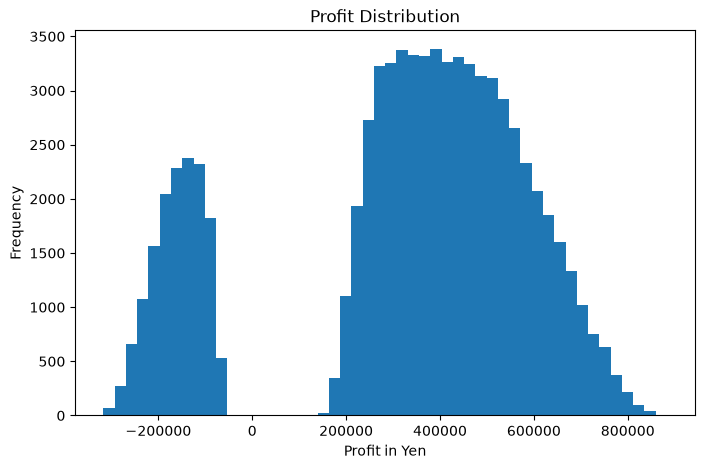

In [16]:
plt.figure(figsize=(8,5))
plt.hist(data.Profit_Yen,bins=50)
plt.title("Profit Distribution")
plt.xlabel("Profit in Yen")
plt.ylabel("Frequency")
plt.show()

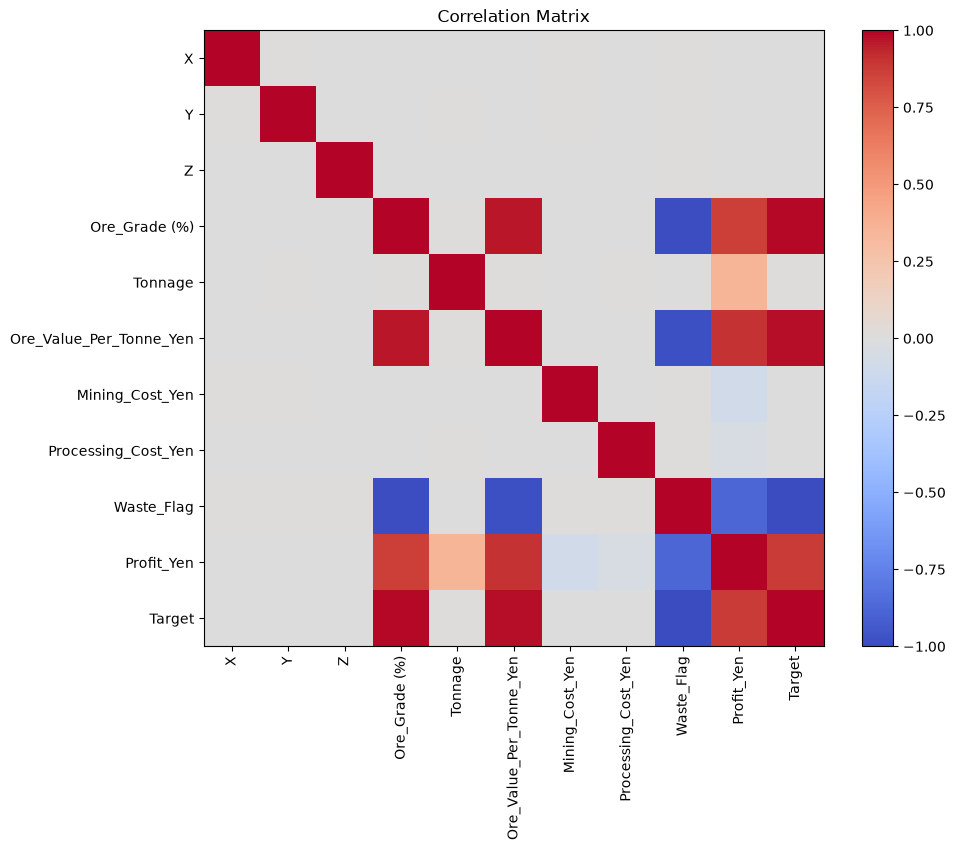

In [17]:
num_data=data.select_dtypes(include=["number"])
corr=num_data.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr,cmap="coolwarm",aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [18]:
corr["Target"].sort_values()

Waste_Flag                -1.000000
Mining_Cost_Yen           -0.004308
Y                         -0.004109
X                         -0.003162
Processing_Cost_Yen       -0.002441
Z                         -0.000270
Tonnage                    0.003775
Profit_Yen                 0.877871
Ore_Value_Per_Tonne_Yen    0.977663
Ore_Grade (%)              0.986047
Target                     1.000000
Name: Target, dtype: float64

In [19]:
corr["Ore_Grade (%)"].sort_values()

Waste_Flag                -0.986047
Mining_Cost_Yen           -0.004963
Y                         -0.004671
X                         -0.003838
Processing_Cost_Yen       -0.003169
Z                         -0.000270
Tonnage                    0.003920
Profit_Yen                 0.865833
Ore_Value_Per_Tonne_Yen    0.964092
Target                     0.986047
Ore_Grade (%)              1.000000
Name: Ore_Grade (%), dtype: float64

In [20]:
X=data[["X","Y","Z","Tonnage","Rock_Type","Mining_Cost_Yen","Processing_Cost_Yen"]]
Y=data["Ore_Grade (%)"]


In [21]:

print(Y.head())

0    51.93
1    59.05
2    63.79
3    64.98
4     0.00
Name: Ore_Grade (%), dtype: float64


In [22]:
print(X.head())

     X    Y   Z  Tonnage  Rock_Type  Mining_Cost_Yen  Processing_Cost_Yen
0  102  186   6     2131  Magnetite               53                   38
1  435  448  82     1550   Hematite               36                   33
2  348  476  94     2414  Magnetite               57                   28
3  270  127  98     1297   Hematite               30                   29
4  106  111  92     1309      Waste               67                   28


In [23]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
X.head()

,X,Y,Z,Tonnage,Rock_Type,Mining_Cost_Yen,Processing_Cost_Yen
0,102,186,6,2131,Magnetite,53,38
1,435,448,82,1550,Hematite,36,33
2,348,476,94,2414,Magnetite,57,28
3,270,127,98,1297,Hematite,30,29
4,106,111,92,1309,Waste,67,28


In [ ]:
from sklearn.preprocessing import LabelEncoder
enc=LabelEncoder()
X["Rock_Type"]=enc.fit_transform(X["Rock_Type"])

# 0-Hematite
# 1-Magnetite
# 2-Waste

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


In [27]:
X_train.shape

(60000, 7)

In [28]:
X_test.shape

(15000, 7)

In [29]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=150,random_state=42)
model.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [30]:
import sklearn.metrics as sk
predictions=model.predict(X_test)
print(sk.mean_absolute_error(Y_test,predictions))



3.055488031111111


In [31]:
sk.r2_score(Y_test,predictions)

0.9717383581933934

In [32]:
Y_train.max()

np.float64(65.0)

In [33]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score
model2=xgb.XGBRegressor(max_depth=12,random_state=42)
mae=-cross_val_score(model2,X_train,Y_train,cv=8,scoring="neg_mean_absolute_error")
model2.fit(X_train,Y_train)
mae.mean()


np.float64(3.363083897995956)

In [35]:

r2=cross_val_score(model2,X_train,Y_train,cv=8,scoring="r2")

In [36]:
r2.mean()

np.float64(0.9664120730450356)

In [37]:
imp=pd.DataFrame({"Feature":X.columns,"Importance":model.feature_importances_}).sort_values(by="Importance",ascending=False)
print(imp)

               Feature  Importance
4            Rock_Type    0.972852
3              Tonnage    0.005668
1                    Y    0.005264
0                    X    0.005215
2                    Z    0.004319
5      Mining_Cost_Yen    0.003586
6  Processing_Cost_Yen    0.003095


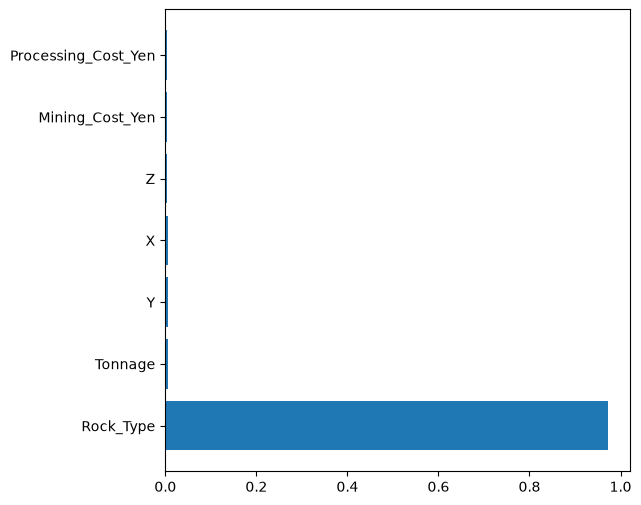

In [38]:
plt.figure(figsize=(6,6))
plt.barh(imp["Feature"],imp["Importance"])
plt.show()

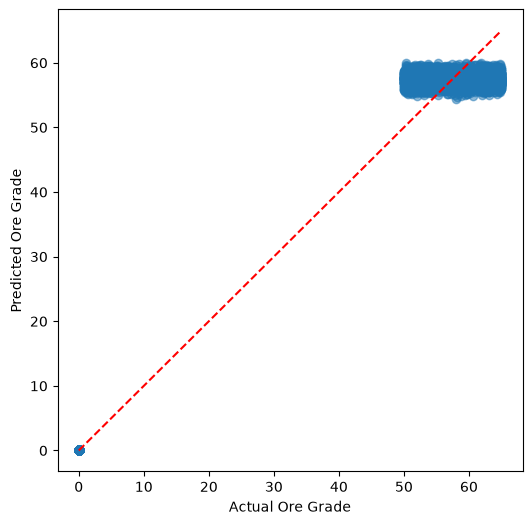

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test,predictions,alpha=0.5)
plt.xlabel("Actual Ore Grade")
plt.ylabel("Predicted Ore Grade")
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],"r--")
plt.show()

In [40]:
results=X_test.copy()
results["Actual_Ore_Grade"]=Y_test
results["Predicted_Ore_Grade"]=predictions
results["Residual"]=Y_test-predictions
results.head()

,X,Y,Z,Tonnage,Rock_Type,Mining_Cost_Yen,Processing_Cost_Yen,Actual_Ore_Grade,Predicted_Ore_Grade,Residual
26837,157,396,62,2376,0,55,34,54.14,56.943733,-2.803733
2592,36,8,27,2134,2,32,36,0.00,0.000000,0.000000
18359,175,325,63,1147,0,33,25,53.38,57.473733,-4.093733
73292,209,16,53,1990,0,65,20,58.61,58.358200,0.251800
60127,115,182,84,1862,2,58,33,0.00,0.000000,0.000000


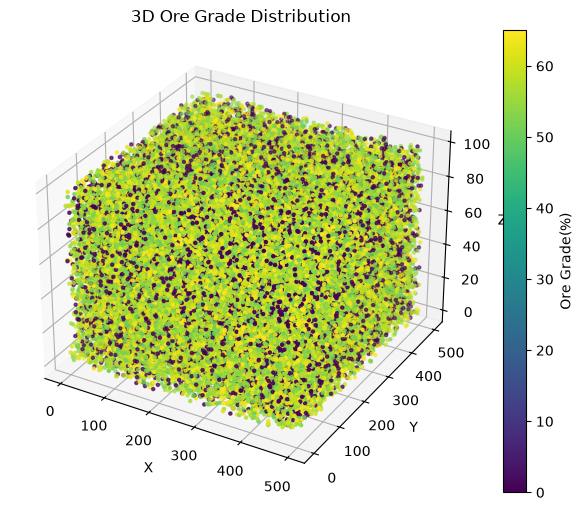

In [41]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
scatter=ax.scatter(data["X"],data["Y"],data["Z"],c=data["Ore_Grade (%)"],cmap="viridis",s=5)
plt.colorbar(scatter,label="Ore Grade(%)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.title("3D Ore Grade Distribution")
plt.show()

# Interactive 3D model

In [51]:
Recovery=0.92
dilution=0.05
smelter_charge=0.03
royalty=0.05
effective_grade=(data["Ore_Grade (%)"]*(1-dilution))
contained=(data["Tonnage"]*effective_grade/100)
recovered=contained*Recovery
gross=recovered*data["Ore_Value_Per_Tonne_Yen"]
smelter_fee=gross*smelter_charge
ROYALTY=gross*royalty
operating_cost=(data["Mining_Cost_Yen"]+data["Processing_Cost_Yen"])
data["Gross"]=gross
data["Net_profit_yen"]=(gross-smelter_fee-ROYALTY-operating_cost)
data["Net_profit_Rupees"]=data["Net_profit_yen"]*0.6

In [43]:
import plotly.express as px 
import plotly.io as pio


In [46]:
fig=px.scatter_3d(data,x="X",y="Y",z="Z",color="Ore_Grade (%)",color_continuous_scale="Viridis",title="Interactive 3D Ore Grade Map",opacity=0.8,hover_data=["Rock_Type","Tonnage","Mining_Cost_Yen","Processing_Cost_Yen","Net_profit_Rupees"],size="Tonnage")
fig.update_traces(marker=dict(size=3))
pio.renderers.default="browser"
fig.show()
fig.update_layout(scene_camera=dict(eye=dict(x=1.8,y=1.8,z=1.3)))
fig.update_layout(template="plotly_dark")
fig.update_layout(scene=dict(xaxis_title="X Coordinate",yaxis_title="Y Coordinate",zaxis_title="Depth"))

In [47]:
fig=px.density_heatmap(data,x="X",y="Y",z="Ore_Grade (%)",histfunc="avg",nbinsx=50,nbinsy=50,color_continuous_scale="Turbo",title="Ore Grade Heatmap")
fig.show(renderer="browser")
fig.update_layout(template="plotly_dark",xaxis_title="X Coordinate",yaxis_title="Y Coordinate",coloraxis_colorbar_title="Ore Grade (%)")

In [52]:
data.to_csv("processed_data.csv",index=False)

In [50]:
import joblib as jb
jb.dump(enc,"Rock encoder.pkl")

['Rock encoder.pkl']